# **Modelo 3**

Dataset: **dataset_caracteristicas_train_V1_ALL.csv**

En este notebook vamos a:

- Extraer el **Feature Importance** del XGBoost optimizado a través del metodo de la **PERMUTATION IMPORTANCE** para determinar las features más relevantes a la hora de predecir si un audio es real o es sintetico;

- Construir un **ranking de features** por Permutation Importance;

- Nos quedamos con las 13 features que según la permutación tienen importancia para la clasificación de audios y que permiten que el F1-score se mantenga alto.

- Entrenar el **modelo final óptimo**: N óptimo + features óptimas + hiperparámetros óptimos;

- Hacer las conclusiones.

### ***PROBLEMAS - DECISIONES TOMADAS***

### ***PROBLEMA: por qué usamos la PERMUTATION para calcular la feature importance?***

Para medir la importancia de cada feature, existen varios métodos. Nosotros elegimos la **Permutation Importance** aplicada sobre el **XGBoost optimizado**.

El metodo de la permutación mezcla al azar los valores de cada feature del XGBoost ya entrenado y mide cuánto cae el F1-score. Es el método más robusto porque evalúa sobre datos de validación que el modelo no usó para construir los árboles y mide el impacto real sobre el F1-score. Además, no tiene sesgos matematicos que tienen otros metodos.

La Permutation Importance responde directamente a la pregunta *¿cuánto empeora el modelo si eliminamos esta variable?*, que es exactamente lo que necesitamos para decidir qué features conservar.

***Cuándo descartamos una variable?***

- Cuando su Permutation Importance es cercana a cero o negativa (mezclar sus valores no perjudica al F1);

- Al retirarla del subconjunto de features, el F1 de validación no cae más de 0.5%.

### ***Bloque 1: configuración***

In [1]:
# Bloque 1: configuración y cargamos las librerias

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    cross_validate, RandomizedSearchCV
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc
)
from scipy.stats import randint, uniform

try:
    from xgboost import XGBClassifier
    XGB_AVAILABLE = True
except ImportError:
    print('XGBoost no instalado')
    XGB_AVAILABLE = False

sns.set_theme(style='whitegrid', palette='Set2', font_scale=1.15)
plt.rcParams['figure.dpi']      = 110
plt.rcParams['axes.titleweight'] = 'bold'

RANDOM_STATE = 42
N_PER_CLASS  = 2500
TEST_SIZE    = 0.20
N_FOLDS      = 5
DATA_PATH    = '../Obtencion_Metricas/dataset_caracteristicas_train_V1_ALL.csv'

# Hiperparámetros óptimos de XGBoost (RandomizedSearchCV, Modelo2_Daniele, N = 4.000)
XGB_OPTIMAL_PARAMS_M2 = {
    'objective'         : 'binary:logistic',
    'eval_metric'       : 'logloss',
    'use_label_encoder' : False,
    'random_state'      : RANDOM_STATE,
    'n_jobs'            : -1,
    'n_estimators'      : 620,
    'max_depth'         : 7,
    'learning_rate'     : 0.09591931665418388,
    'subsample'         : 0.602208846849441,
    'colsample_bytree'  : 0.6379995910112717,
    'reg_alpha'         : 0.7722447692966574,
    'reg_lambda'        : 1.3942205669037757,
    'min_child_weight'  : 1,
}

### ***Bloque 2: desde el modelo 2 definimos que el n optimo es 4.000***

En el modelo 1 habiamos visto que el plateau era de 2.240, pero no se trataba de un plateau ideal que garantizaba el mismo F1-score que el F1-score calculado con 4.000 audios, porque las learning curves nos mostraban curvas de validación que seguian creciendo después del valor 2.240.

Por esta razón, en el modelo 2 decidimos utilizar todo el conjunto de entrenamiento y también ahora, para proceder con el calculo de las features importance, definimos como numero optimo de audios 4.000.

In [2]:
#  Bloque 2: desde el modelo 2 el n optimo es 4.000

N_OPTIMAL_FROM_M2 = 4000 

print(f'N óptimo de muestras configurado: {N_OPTIMAL_FROM_M2:,} muestras')

N óptimo de muestras configurado: 4,000 muestras


## **SECCIÓN 1**: Pipeline de Datos con N Óptimo

### ***Bloque 3: definimos la pipeline de datos***

In [3]:
#  Bloque 3: pipeline de datos

df_full     = pd.read_csv(DATA_PATH)
df_bonafide = df_full[df_full['label'] == 'bonafide'].copy()
df_spoof    = df_full[df_full['label'] == 'spoof'].copy()

df_bon_sample = df_bonafide.sample(n=min(len(df_bonafide), N_PER_CLASS), random_state=RANDOM_STATE)

attack_counts = df_spoof['attack_id'].value_counts()
proportions   = attack_counts / attack_counts.sum()
n_per_attack  = (proportions * N_PER_CLASS).astype(int)
deficit       = N_PER_CLASS - n_per_attack.sum()
for atk in n_per_attack.nlargest(abs(deficit)).index:
    n_per_attack[atk] += int(np.sign(deficit))

spoof_samples = []
for attack_id, n in n_per_attack.items():
    subset = df_spoof[df_spoof['attack_id'] == attack_id]
    spoof_samples.append(subset.sample(n=min(n, len(subset)), random_state=RANDOM_STATE))

df_balanced  = pd.concat([df_bon_sample, pd.concat(spoof_samples)]).sample(
    frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

FEATURE_COLS = [c for c in df_balanced.columns if c not in ['file_name', 'attack_id', 'label']]
X_all        = df_balanced[FEATURE_COLS]
y_all        = df_balanced['label']

X_train_all, X_test, y_train_all, y_test = train_test_split(
    X_all, y_all, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_all
)

le          = LabelEncoder().fit(['bonafide', 'spoof'])
y_train_enc = le.transform(y_train_all)
y_test_enc  = le.transform(y_test)

# Submuestra con N óptimo
idx_opt = []
for cls in [0, 1]:
    cls_idx = np.where(y_train_enc == cls)[0]
    take    = min(N_OPTIMAL_FROM_M2 // 2, len(cls_idx))
    rng     = np.random.default_rng(RANDOM_STATE)
    idx_opt.extend(rng.choice(cls_idx, take, replace=False).tolist())

X_train = X_train_all.iloc[idx_opt]
y_train = y_train_enc[idx_opt]

print('Pipeline de datos:')
print(f'Conjunto de Train completo  : {len(X_train_all):,} registros')
print(f'Conjunto deTrain óptimo (N) : {len(X_train):,} registros')
print(f'Conjunto de Test            : {len(X_test):,} registros')
print(f'Features totales            : {len(FEATURE_COLS)}')

Pipeline de datos:
Conjunto de Train completo  : 4,000 registros
Conjunto deTrain óptimo (N) : 4,000 registros
Conjunto de Test            : 1,000 registros
Features totales            : 34


## **SECCIÓN 2**: Feature Importance con PERMUTACIÓN

### ***Bloque 4: PERMUTATION IMPORTANCE del XGBoost optimizado***

In [4]:
#  Bloque 4: PERMUTATION IMPORTANCE del XGBOOST OPTIMIZADO

if not XGB_AVAILABLE:
    raise RuntimeError('XGBoost para calcular las feature importances')

xgb_opt = XGBClassifier(**XGB_OPTIMAL_PARAMS_M2)
xgb_opt.fit(X_train, y_train)

# Permutation Importance: usamos 500 muestras del train como conjunto de validación
idx_val = np.random.default_rng(RANDOM_STATE).choice(
    len(X_train), size=min(500, len(X_train)), replace=False
)
X_val_perm = X_train.iloc[idx_val]
y_val_perm = y_train[idx_val]

perm_result = permutation_importance(
    xgb_opt, X_val_perm, y_val_perm,
    n_repeats=10, scoring='f1',
    n_jobs=-1, random_state=RANDOM_STATE
)

fi_perm = pd.Series(
    perm_result.importances_mean,
    index=FEATURE_COLS
).sort_values(ascending=False)

print('PERMUTATION IMPORTANCE XGBOOST OPTIMIZADO')
print('Mostramos a continuación las 10 features más importantes:')
print('Los valores representan la caída del F1-score del modelo al mezclar los valores de cada feature')
for i, (feat, val) in enumerate(fi_perm.head(10).items(), 1):
    print(f'{i:>2}. {feat:<30} {val:+.4f}')

PERMUTATION IMPORTANCE XGBOOST OPTIMIZADO
Mostramos a continuación las 10 features más importantes:
Los valores representan la caída del F1-score del modelo al mezclar los valores de cada feature
 1. signal_mean                    +0.0129
 2. mfcc_9_std                     +0.0109
 3. mfcc_6_mean                    +0.0105
 4. mfcc_7_mean                    +0.0095
 5. mfcc_4_std                     +0.0065
 6. mfcc_5_mean                    +0.0050
 7. mfcc_13_mean                   +0.0042
 8. mfcc_2_std                     +0.0038
 9. mfcc_8_std                     +0.0032
10. mfcc_3_mean                    +0.0030


### ***Bloque 5: ranking completo de todas las features por permutation importance***

In [5]:
#  Bloque 5: RANKING COMPLETO POR PERMUTATION IMPORTANCE

print('RANKING COMPLETO DE FEATURES (PERMUTATION IMPORTANCE)')
print(f'{"Rank":<5} {"Feature":<30} {"Importancia":>12} {"":>5}')
print('-' * 57)
for rank, (feat, val) in enumerate(fi_perm.items(), 1):
    flag = ' ←' if val > 0 else ''
    print(f'{rank:<5} {feat:<30} {val:>+12.4f}{flag}')
print()
n_relevant = (fi_perm > 0).sum()
print(f'Número de features con importancia positiva (aportan al F1): {n_relevant}/{len(fi_perm)}')
print('XGBoost no disponible')

RANKING COMPLETO DE FEATURES (PERMUTATION IMPORTANCE)
Rank  Feature                         Importancia      
---------------------------------------------------------
1     signal_mean                         +0.0129 ←
2     mfcc_9_std                          +0.0109 ←
3     mfcc_6_mean                         +0.0105 ←
4     mfcc_7_mean                         +0.0095 ←
5     mfcc_4_std                          +0.0065 ←
6     mfcc_5_mean                         +0.0050 ←
7     mfcc_13_mean                        +0.0042 ←
8     mfcc_2_std                          +0.0038 ←
9     mfcc_8_std                          +0.0032 ←
10    mfcc_3_mean                         +0.0030 ←
11    mfcc_10_std                         +0.0024 ←
12    mfcc_9_mean                         +0.0024 ←
13    mfcc_11_mean                        +0.0002 ←
14    signal_std                          +0.0000
15    mfcc_1_std                          +0.0000
16    mfcc_2_mean                         +0.0000
17    

### ***Bloque 6: REPRESENTACIÓN GRÁFICA DE LA PERMUTATION IMPORTANCE***

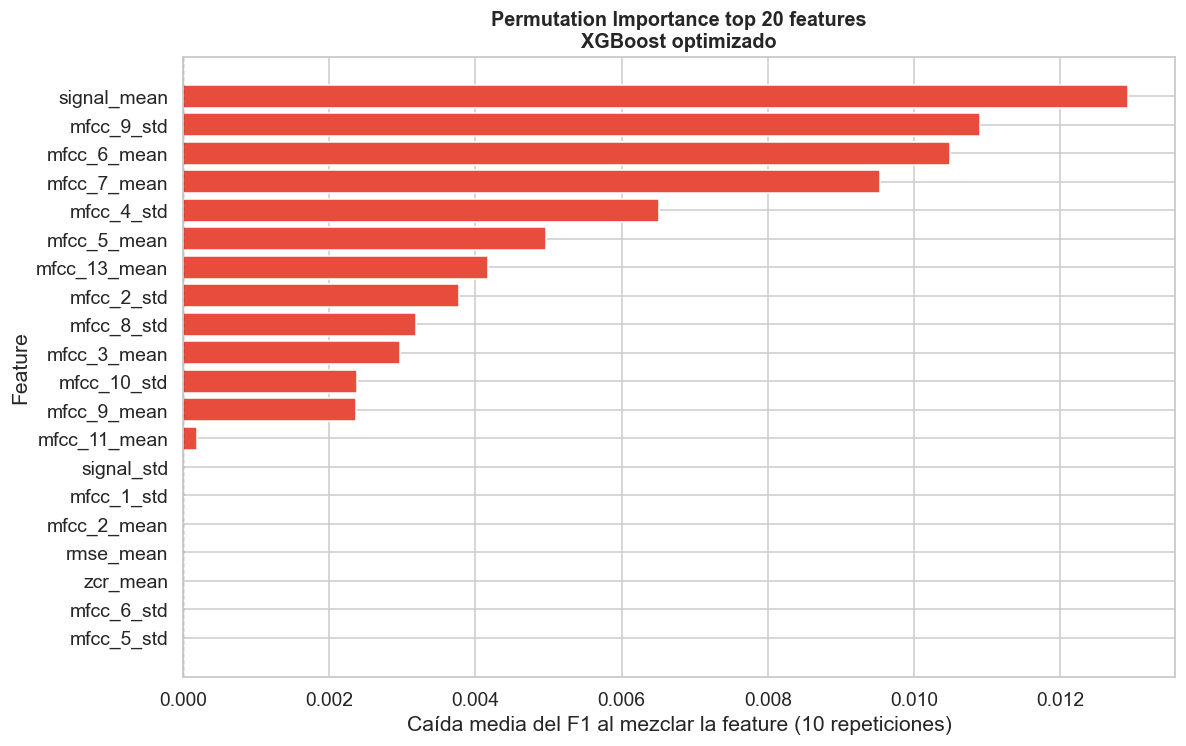

Gráfico guardado: modelo3_feature_importance.png


In [6]:
#  Bloque 6: REPRESENTACIÓN GRÁFICA DE LA PERMUTATION IMPORTANCE

top_n = 20
top_feats = fi_perm.head(top_n)
colors = ['#e74c3c' if v > 0 else '#95a5a6' for v in top_feats.values]

fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(top_feats.index[::-1], top_feats.values[::-1], color=colors[::-1])
ax.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
ax.set_title(
    f'Permutation Importance top {top_n} features\nXGBoost optimizado',
    fontsize=13, fontweight='bold'
)
ax.set_xlabel('Caída media del F1 al mezclar la feature (10 repeticiones)')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.savefig('modelo3_feature_importance.png', dpi=110, bbox_inches='tight')
plt.show()
print('Gráfico guardado: modelo3_feature_importance.png')

### ***Bloque 7: definición variable `fi_consolidated`***

Definimos la variable `fi_consolidated` que utilizaremos después para el barrido de features y la selección final.

Dado que usamos un único método (Permutation Importance), `fi_consolidated` representa la serie de features que tienen una importancia positiva. Las features que tienen una importancia negativa significa que al eliminarlas no perjudican el F1-score del modelo, entonces podemos quitarla. 

La variable `ranked_features` lista los nombres de las features en ese orden de prioridad (desde la que tiene más impacto hasta la que tiene menos).

In [7]:
# Bloque 7: VARIABLE fi_consolidated

# fi_consolidated es la Permutation Importance con valores negativos recortados a 0 y ordenada de manera descendente
fi_consolidated = fi_perm.clip(lower=0).sort_values(ascending=False)
ranked_features = fi_consolidated.index.tolist()

# Tabla completa
print('fi_consolidated')
print(f'Top 10 features por Permutation Importance:')
for i, (feat, val) in enumerate(fi_consolidated.head(10).items(), 1):
    print(f'  {i:>2}. {feat:<30} {val:+.4f}')
print(f'Número total defeatures con importancia > 0: {(fi_consolidated > 0).sum()}/{len(fi_consolidated)}')

fi_consolidated
Top 10 features por Permutation Importance:
   1. signal_mean                    +0.0129
   2. mfcc_9_std                     +0.0109
   3. mfcc_6_mean                    +0.0105
   4. mfcc_7_mean                    +0.0095
   5. mfcc_4_std                     +0.0065
   6. mfcc_5_mean                    +0.0050
   7. mfcc_13_mean                   +0.0042
   8. mfcc_2_std                     +0.0038
   9. mfcc_8_std                     +0.0032
  10. mfcc_3_mean                    +0.0030
Número total defeatures con importancia > 0: 13/34


### ***CONCLUSIONES DEL ANÁLISIS DE PERMUTATION IMPORTANCE***

Después de `signal_mean`, las features de los coeficientes MFCC encabezan el ranking: cuando los valores de cada feature se mezclan al azar, el F1 cae de forma significativa. Son las variables que más ayudan al modelo a distinguir voces reales de voces sintéticas.

Son 13 las features que tienen una influencia sobre el F1-score del XGBoost optimizado.

## **SECCIÓN 3**: Modelo final optimo

Entrenamos el modelo definitivo con la combinación ganadora: **N = 4.000 muestras** + **features con Permutation Importance > 0** + **hiperparámetros optimizados** (`XGB_OPTIMAL_PARAMS_M2`).

> **Nota**: el Val F1 que aparece en la cross-validation no reproduce exactamente el F1 = 0.9484 del modelo anterior. Esto no indica ningún error: la causa es el **orden de las filas de `X_train`**. En el Modelo 2, `X_train` sale directamente de `train_test_split()`. En el Modelo 3, `X_train = X_train_all.iloc[idx_opt]` reordena las mismas 4.000 muestras de otro modo, lo que cambia la asignación de pliegues del `StratifiedKFold` aunque la semilla sea la misma. Es estadísticamente normal y esperado.

### ***Bloque 8: Features seleccionadas por permutation importance***


In [8]:
#  Bloque 8: para seleccionar las features tomamos directamente las features con importancia > 0, o sea
#  las que perjudican al modelo si se eliminaran.

FINAL_FEATURES = [f for f in ranked_features if fi_perm[f] > 0]
N_FEATS_OPT    = len(FINAL_FEATURES)

print(f'FEATURES SELECCIONADAS SEGÚN PERMUTATION IMPORTANCE')
print('-' * 60)
groups = {
    'MFCCs (media)'     : [f for f in FINAL_FEATURES if 'mfcc' in f and 'mean' in f],
    'MFCCs (desv. std)' : [f for f in FINAL_FEATURES if 'mfcc' in f and 'std'  in f],
    'Espectral'         : [f for f in FINAL_FEATURES if 'spectral' in f or 'rolloff' in f],
    'Temporales/energía': [f for f in FINAL_FEATURES if f in
                           ['zcr_mean', 'tempo_bpm', 'rmse_mean', 'signal_mean', 'signal_std']],
}
for grupo, feats in groups.items():
    if feats:
        print(f'\n  {grupo}:')
        for f in feats:
            print(f'  {f:<30}  PI = {fi_perm[f]:+.4f}')

discarded = [f for f in FEATURE_COLS if f not in FINAL_FEATURES]
print(f'\n  Descartadas ({len(discarded)}): {", ".join(discarded)}')
print(f'\n  Reducción: de {len(FEATURE_COLS)} a {N_FEATS_OPT} features')

# Ranking de features por importancia consolidada
ranked_features = fi_consolidated.index.tolist()

if not XGB_AVAILABLE:
    raise RuntimeError(
        'XGBoost no está instalado: el barrido usa el mismo XGBoost optimizado'
    )

FEATURES SELECCIONADAS SEGÚN PERMUTATION IMPORTANCE
------------------------------------------------------------

  MFCCs (media):
  mfcc_6_mean                     PI = +0.0105
  mfcc_7_mean                     PI = +0.0095
  mfcc_5_mean                     PI = +0.0050
  mfcc_13_mean                    PI = +0.0042
  mfcc_3_mean                     PI = +0.0030
  mfcc_9_mean                     PI = +0.0024
  mfcc_11_mean                    PI = +0.0002

  MFCCs (desv. std):
  mfcc_9_std                      PI = +0.0109
  mfcc_4_std                      PI = +0.0065
  mfcc_2_std                      PI = +0.0038
  mfcc_8_std                      PI = +0.0032
  mfcc_10_std                     PI = +0.0024

  Temporales/energía:
  signal_mean                     PI = +0.0129

  Descartadas (21): signal_std, rmse_mean, zcr_mean, tempo_bpm, mfcc_1_mean, mfcc_1_std, mfcc_2_mean, mfcc_3_std, mfcc_4_mean, mfcc_5_std, mfcc_6_std, mfcc_7_std, mfcc_8_mean, mfcc_10_mean, mfcc_11_std, mfcc_12_m

### ***Bloque 9: grafico de las features seleccionadas para el modelo final***

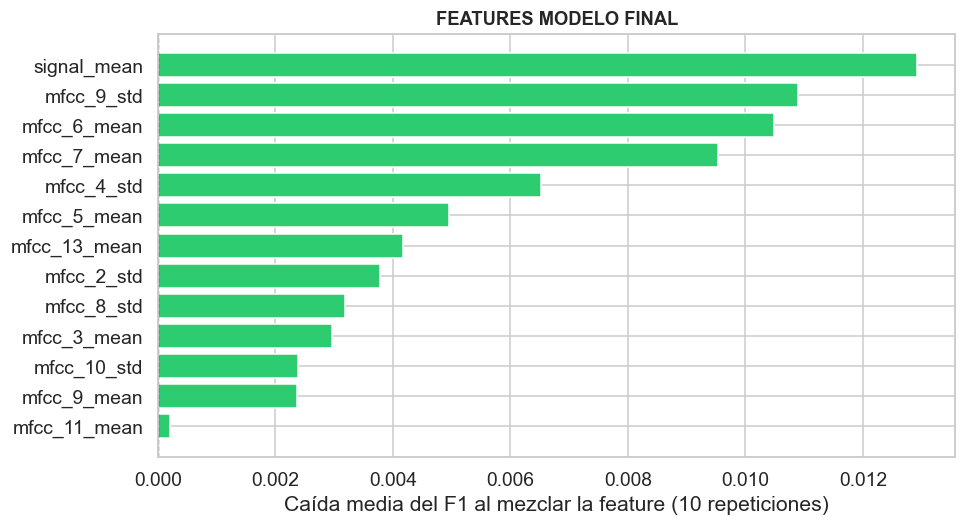

Gráfico guardado: modelo3_feature_importance.png


In [9]:
#  Bloque 11: GRÁFICO DE LAS FEATURES SELECCIONADAS

selected_perm = fi_perm[FINAL_FEATURES].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(selected_perm.index[::-1], selected_perm.values[::-1], color='#2ecc71')
ax.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
ax.set_title(f'FEATURES MODELO FINAL',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Caída media del F1 al mezclar la feature (10 repeticiones)')
plt.tight_layout()
plt.savefig('modelo3_feature_importance.png', dpi=110, bbox_inches='tight')
plt.show()
print(f'Gráfico guardado: modelo3_feature_importance.png')

### ***Bloque 10: entrenamiento y evaluación del modelo final***

Entrenamos con todos los 4.000 audios de train, las 13 features seleccionadas mediante la permutación y los parametros optimos que calculamos en el modelo 2. Luego evaluamos sobre el conjunto de test sellado compuesto por los 1.000 audios que el modelo nunca ha visto.

In [10]:
#  Bloque 10: entrenamiento del modelo final

# Validación cruzada del modelo final (con features óptimas)
X_train_final = X_train_all[FINAL_FEATURES]
X_test_final  = X_test[FINAL_FEATURES]

if not XGB_AVAILABLE:
    raise RuntimeError(
        'XGBoost es obligatorio para el modelo final reproduciendo el paso anterior'
    )

final_model = XGBClassifier(**XGB_OPTIMAL_PARAMS_M2)

cv_final = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
cv_final_out = cross_validate(
    final_model, X_train_final, y_train_enc,
    cv=cv_final,
    scoring={'f1': 'f1', 'roc_auc': 'roc_auc', 'recall': 'recall', 'precision': 'precision'},
    return_train_score=True, n_jobs=-1
)

print('Modelo final - CV con features optimas')
print('-' * 60)
for metric in ['f1', 'roc_auc', 'recall', 'precision']:
    tr = cv_final_out[f'train_{metric}'].mean()
    va = cv_final_out[f'test_{metric}'].mean()
    gap = tr - va
    print(f'  {metric.capitalize():<12}: Train={tr:.4f} | Val={va:.4f} | GAP={gap:+.4f}')

# Entrenar con todo el train para evaluación en test
final_model.fit(X_train_final, y_train_enc)
y_pred_final = final_model.predict(X_test_final)
y_proba_final = final_model.predict_proba(X_test_final)[:, 1]

print('\nModelo final - evaluación con conjunto de test')
print('-' * 60)
final_test_metrics = {
    'f1'       : f1_score(y_test_enc, y_pred_final),
    'roc_auc'  : roc_auc_score(y_test_enc, y_proba_final),
    'recall'   : recall_score(y_test_enc, y_pred_final),
    'precision': precision_score(y_test_enc, y_pred_final),
    'accuracy' : accuracy_score(y_test_enc, y_pred_final)
}
for k, v in final_test_metrics.items():
    print(f'  {k.capitalize():<12}: {v:.4f}')

print(f'\nFeatures usadas : {N_FEATS_OPT} de {len(FEATURE_COLS)}')
print(classification_report(y_test_enc, y_pred_final,
                             target_names=['bonafide', 'spoof']))

Modelo final - CV con features optimas
------------------------------------------------------------
  F1          : Train=1.0000 | Val=0.9093 | GAP=+0.0907
  Roc_auc     : Train=1.0000 | Val=0.9698 | GAP=+0.0302
  Recall      : Train=1.0000 | Val=0.9005 | GAP=+0.0995
  Precision   : Train=1.0000 | Val=0.9184 | GAP=+0.0816

Modelo final - evaluación con conjunto de test
------------------------------------------------------------
  F1          : 0.9032
  Roc_auc     : 0.9700
  Recall      : 0.8960
  Precision   : 0.9106
  Accuracy    : 0.9040

Features usadas : 13 de 34
              precision    recall  f1-score   support

    bonafide       0.90      0.91      0.90       500
       spoof       0.91      0.90      0.90       500

    accuracy                           0.90      1000
   macro avg       0.90      0.90      0.90      1000
weighted avg       0.90      0.90      0.90      1000



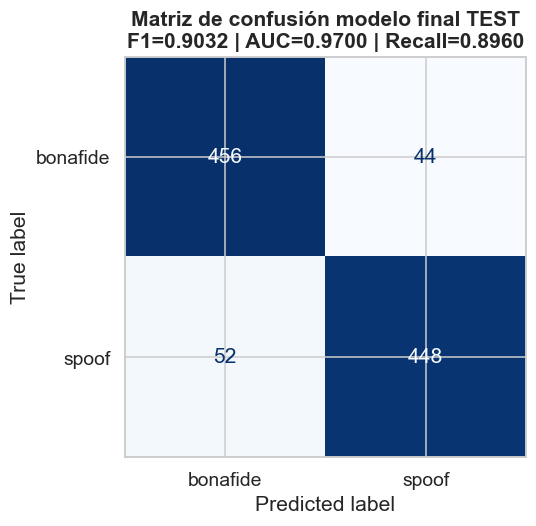

Gráfico guardado: modelo3_confusion_final.png


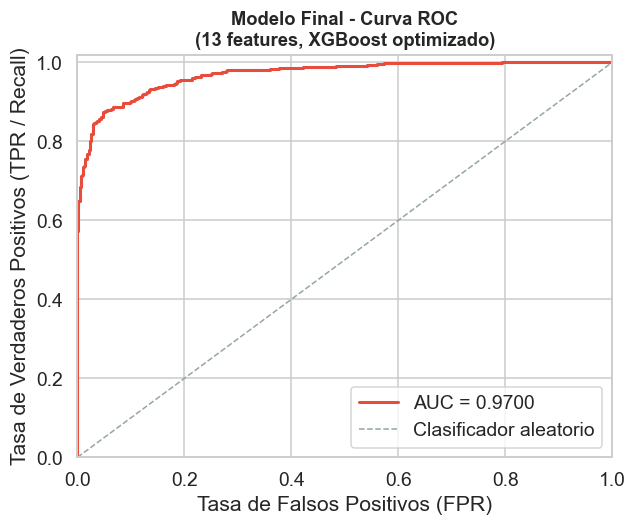

Gráfico guardado: modelo3_roc_final.png


In [11]:
#  Bloque 11: MATRIZ DE CONFUSIÓN + CURVA ROC DEL MODELO FINAL

fig, ax = plt.subplots(figsize=(6, 5))

cm = confusion_matrix(y_test_enc, y_pred_final)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['bonafide', 'spoof'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(
    f'Matriz de confusión modelo final TEST\n'
    f'F1={final_test_metrics["f1"]:.4f} | AUC={final_test_metrics["roc_auc"]:.4f} | '
    f'Recall={final_test_metrics["recall"]:.4f}'
)

plt.tight_layout()
plt.savefig('modelo3_confusion_final.png', bbox_inches='tight', dpi=120)
plt.show()
print('Gráfico guardado: modelo3_confusion_final.png')

# CURVA ROC
fpr, tpr, _ = roc_curve(y_test_enc, y_proba_final)
roc_auc_val = auc(fpr, tpr)

fig2, ax2 = plt.subplots(figsize=(6, 5))
ax2.plot(fpr, tpr, color='#e74c3c', lw=2,
         label=f'AUC = {roc_auc_val:.4f}')
ax2.plot([0, 1], [0, 1], color='#95a5a6', lw=1, linestyle='--', label='Clasificador aleatorio')
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.02])
ax2.set_xlabel('Tasa de Falsos Positivos (FPR)')
ax2.set_ylabel('Tasa de Verdaderos Positivos (TPR / Recall)')
ax2.set_title(f'Modelo Final - Curva ROC\n'
              f'({N_FEATS_OPT} features, XGBoost optimizado)',
              fontsize=12, fontweight='bold')
ax2.legend(loc='lower right')
plt.tight_layout()
plt.savefig('modelo3_roc_final.png', bbox_inches='tight', dpi=120)
plt.show()
print('Gráfico guardado: modelo3_roc_final.png')

## **SECCIÓN 4**: cuadro comparativo final

Comparamos los tres modelos del proyecto:

| Modelo | Descripción |
|--------|-------------|
| **Modelo 1** | XGBoost, sin optimización, 34 features, N = 4.000 (modelo base) |
| **Modelo 2** | XGBoost optimizado, 34 features, N = 4.000 |
| **Modelo 3** | XGBoost optimizado, 13 features, N = 4.000 |

In [12]:
#  Bloque 12: cuadro comparativo de los 3 modelos implementados

# Recalcular M1 baseline con train completo y todas las features
m1_model = XGBClassifier(n_estimators=100, n_jobs=-1, random_state=RANDOM_STATE)
m1_cv    = cross_validate(
    m1_model, X_train_all, y_train_enc,
    cv=StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE),
    scoring={'f1': 'f1', 'roc_auc': 'roc_auc'},
    return_train_score=True, n_jobs=-1
)
m1_model.fit(X_train_all, y_train_enc)
m1_pred   = m1_model.predict(X_test)
m1_proba  = m1_model.predict_proba(X_test)[:, 1]
m1_f1_val = m1_cv['test_f1'].mean()
m1_f1_tst = f1_score(y_test_enc, m1_pred)
m1_auc    = roc_auc_score(y_test_enc, m1_proba)
m1_gap    = m1_cv['train_f1'].mean() - m1_f1_val

# Recalcular M2 (N óptimo, features completas, regularización)
m2_model = XGBClassifier(**XGB_OPTIMAL_PARAMS_M2)
m2_cv = cross_validate(
    m2_model, X_train, y_train,
    cv=StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE),
    scoring={'f1': 'f1', 'roc_auc': 'roc_auc'},
    return_train_score=True, n_jobs=-1
)
m2_model.fit(X_train, y_train)
m2_pred  = m2_model.predict(X_test)
m2_proba = m2_model.predict_proba(X_test)[:, 1]
m2_f1_val = m2_cv['test_f1'].mean()
m2_f1_tst = f1_score(y_test_enc, m2_pred)
m2_auc    = roc_auc_score(y_test_enc, m2_proba)
m2_gap    = m2_cv['train_f1'].mean() - m2_f1_val

# M3 (features óptimas, train completo)
m3_f1_val = cv_final_out['test_f1'].mean()
m3_f1_tst = final_test_metrics['f1']
m3_auc    = final_test_metrics['roc_auc']
m3_gap    = cv_final_out['train_f1'].mean() - m3_f1_val

# Tabla
print('EVOLUCIÓN COMPLETA: MODELO1 (XGBoost Base) → MODELO2 (XGBoost optimizado) → MODELO3 (Features optimas)')
print()
print(f'  {"Modelo":<10} {"N Train":>8} {"N Feats":>8} {"CV Val F1":>10} {"Test F1":>10} {"Test AUC":>10} {"GAP":>8}')
print('  ' + '-' * 70)
rows = [
    ('Modelo 1 (XGB Base, sin optim.)',         len(X_train_all), len(FEATURE_COLS), m1_f1_val, m1_f1_tst, m1_auc, m1_gap),
    ('Modelo 2 (XGB optim., 34 feat.)',   len(X_train_all), len(FEATURE_COLS), m2_f1_val, m2_f1_tst, m2_auc, m2_gap),
    ('Modelo 3 (XGB optim., 13 feat.)',   len(X_train_all), N_FEATS_OPT,       m3_f1_val, m3_f1_tst, m3_auc, m3_gap),
]
for row in rows:
    name, n_tr, n_ft, cv_f1, tst_f1, tst_auc, gap = row
    print(f'  {name:<10} {n_tr:>8,} {n_ft:>8} {cv_f1:>10.4f} {tst_f1:>10.4f} {tst_auc:>10.4f} {gap:>+8.4f}')

print()
best_row = max(rows, key=lambda r: r[3])  # Mejor CV Val F1
print(f'MEJOR MODELO: {best_row[0]}')
print(f'CV Val F1 = {best_row[3]:.4f} | Test F1 = {best_row[4]:.4f} | Test AUC = {best_row[5]:.4f}')
print(f'N muestras = {best_row[1]:,} | N features = {best_row[2]}')


EVOLUCIÓN COMPLETA: MODELO1 (XGBoost Base) → MODELO2 (XGBoost optimizado) → MODELO3 (Features optimas)

  Modelo      N Train  N Feats  CV Val F1    Test F1   Test AUC      GAP
  ----------------------------------------------------------------------
  Modelo 1 (XGB Base, sin optim.)    4,000       34     0.9402     0.9512     0.9907  +0.0598
  Modelo 2 (XGB optim., 34 feat.)    4,000       34     0.9446     0.9546     0.9922  +0.0554
  Modelo 3 (XGB optim., 13 feat.)    4,000       13     0.9093     0.9032     0.9700  +0.0907

MEJOR MODELO: Modelo 2 (XGB optim., 34 feat.)
CV Val F1 = 0.9446 | Test F1 = 0.9546 | Test AUC = 0.9922
N muestras = 4,000 | N features = 34


### ***Bloque 13: guardamos la configuración para los pasos sucesivos***

Para que en el código sucesivo sepamos qué hiperparámetros usar y qué features extraer del audio, es buena practica guardar la información en un JSON.

In [13]:
# Bloque 13: guardamos la configuración para los pasos sucesivos

import json, os

config_paso4 = {
    'best_model_name'    : 'XGBoost',
    'best_model_params'  : dict(XGB_OPTIMAL_PARAMS_M2),
    'final_features'     : FINAL_FEATURES,
    'n_features_selected': N_FEATS_OPT,
    'n_features_total'   : len(FEATURE_COLS),
    'n_optimal_train'    : N_OPTIMAL_FROM_M2,
    'cv_val_f1'          : round(m3_f1_val, 4),
    'test_f1'            : round(m3_f1_tst, 4),
    'test_auc'           : round(m3_auc, 4),
    'discarded_features' : discarded
}

config_path = 'config_modelo_final_paso4.json'
with open(config_path, 'w', encoding='utf-8') as f:
    json.dump(config_paso4, f, indent=2, ensure_ascii=False)

print(f'Configuración guardada en: {os.path.abspath(config_path)}')
print()
print('Contenido del archivo de configuración:')
print(json.dumps(config_paso4, indent=2, ensure_ascii=False))

Configuración guardada en: c:\Users\PC\OneDrive\Desktop\GIT_DANIELE\Reto_Inteligencia_Artificial_Liliana_Daniele_Alexis\Modelos\config_modelo_final_paso4.json

Contenido del archivo de configuración:
{
  "best_model_name": "XGBoost",
  "best_model_params": {
    "objective": "binary:logistic",
    "eval_metric": "logloss",
    "use_label_encoder": false,
    "random_state": 42,
    "n_jobs": -1,
    "n_estimators": 620,
    "max_depth": 7,
    "learning_rate": 0.09591931665418388,
    "subsample": 0.602208846849441,
    "colsample_bytree": 0.6379995910112717,
    "reg_alpha": 0.7722447692966574,
    "reg_lambda": 1.3942205669037757,
    "min_child_weight": 1
  },
  "final_features": [
    "signal_mean",
    "mfcc_9_std",
    "mfcc_6_mean",
    "mfcc_7_mean",
    "mfcc_4_std",
    "mfcc_5_mean",
    "mfcc_13_mean",
    "mfcc_2_std",
    "mfcc_8_std",
    "mfcc_3_mean",
    "mfcc_10_std",
    "mfcc_9_mean",
    "mfcc_11_mean"
  ],
  "n_features_selected": 13,
  "n_features_total": 34,
  

## **CONCLUSIONES DEL MODELO 3**

Hemos entrenamos el XGBoost optimizado del Modelo 2 y calculado la **Permutation Importance** de las 34 features. La permutación es el método más honesto porque mide directamente cuánto cae el F1 cuando se elimina la información de cada variable.

Descartamos las 21 features con Permutation Importance inferior o igual a 0 y nos quedamos con **13 features**, reduciendo las features originales de un 62%.

Implementamos el **modelo final optimo**, entrenando el XGBoost con `N = 4.000` muestras + **13 features** + `XGB_OPTIMAL_PARAMS_M2` y lo evaluamos sobre el conjunto de test sellado (1.000 audios).

### Resultados:

| Modelo | Descripción | Val F1 (CV) | Test F1 | Test AUC |
|--------|-------------|-------------|---------|----------|
| **Modelo 1** | XGBoost, sin optimización, 34 features, N = 4.000 (modelo base) | 0.9402 | 0.9512 | 0.9907 |
| **Modelo 2** | XGBoost optimizado, 34 features, N = 4.000 | 0.9446 | 0.9546 | 0.9922 |
| **Modelo 3** | XGBoost optimizado, 13 features, N = 4.000 | 0.9093 | 0.9032 | 0.9700 |


- La reducción de features implica una caída del F1, pero el nivel sigue siendo muy alto: al pasar de 34 a 13 features, el F1-score del conjunto de test baja de 0.95 a 0.90, una reducción del 5%.
Un F1 de 0.90 sobre el conjunto de test sigue siendo un resultado excelente para una tarea de detección de voz sintética en producción. En términos prácticos, la diferencia del 5% de F1 que se pierde se compra con un ahorro computacional concreto:

  - **62% menos de variables** que hay que calcular para cada audio (de 34 a 13 features);

  - **Extracción de features más rápida:** en un sistema en tiempo real, calcular 13 coeficientes MFCC en lugar de 34 features acústicas reduce el coste de respuesta;

  - **Pipeline más simple y mantenible:** con menos variables hay menos código, menos tests y menos riesgo de errores al actualizar el sistema.

- **Las features más importantes son coeficientes MFCC:** los descriptores de media y desviación estándar de los coeficientes Mel-Frequency Cepstral (MFCC) son los que mayor impacto tienen en la detección de voces sintéticas. Los MFCCs capturan la textura espectral de la voz, que es donde las voces generadas artificialmente difieren más de las reales.

- **Los modelos no generan overfitting.**

### ***Que nos llevamos al modelo 4?***

1. **Modelo:** XGBoost con hiperparámetros optimizados;
2. **Features:** Top-N seleccionadas por importancia consolidada;
3. **Protocolo:** Entrenar SOLO con A01-A04, testear con A05-A06;
4. **Pregunta clave:** ¿Aprendió a detectar voz humana en general o memorizó los 4 ataques?